# Week 2, Day 2: TikTok Social Media Analytics

**Goal:** calculate every social media metric for TikTok posts, interpret the results, and visualize them.

**Data:** `social_media_raw.csv` (raw file from the previous notebook). This notebook filters it to TikTok and applies only the *minimum cleaning needed for correct metrics*. The full step-by-step cleaning walkthrough is a separate notebook.

**Structure:** each section computes results, shows a chart or table, and prints a finding that is generated from the numbers, so the interpretation always matches the data.

## Metrics implemented

| Layer | Metric | Formula | What it tells you |
|---|---|---|---|
| Exposure | Frequency | impressions / reach | How many times the average viewer saw the post |
| Engagement | Engagements | likes + comments + shares + saves | Total interactions |
| Engagement | Engagement rate by reach (ERR) | engagements / reach x 100 | Content quality among people who saw it |
| Engagement | Engagement rate by impressions | engagements / impressions x 100 | Interaction per display |
| Engagement | Engagement rate by followers | engagements / followers x 100 | Comparable across accounts |
| Engagement | Amplification rate | shares / followers x 100 | Virality potential |
| Video | View rate | views / impressions x 100 | Strength of the hook |
| Video | Completion rate | avg watch time / video length x 100 | How much of the video is watched |
| Conversion | CTR | link clicks / impressions x 100 | Interest in the call to action |
| Conversion | Conversion rate | conversions / link clicks x 100 | Clicks that turned into results |
| Audience | Follower growth rate | new followers / followers x 100 | Ability to attract followers |

**Rule used throughout:** group-level rates are computed as *total numerator / total denominator* (not an average of per-post rates), using only rows where both values are valid.

## 1. Setup and load

In [1]:
import logging

logging.basicConfig(
    filename="w2d2.log",
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)

logger=logging.getLogger("w2d2")
print("Logging is set up. Check w2d2.log for log messages.")

Logging is set up. Check w2d2.log for log messages.


In [2]:
logger.info("Week 2 Day 2: Logging is set up successfully.")


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
COLOR, ACCENT = "#2E86AB", "#E4572E"

raw = pd.read_csv("social_media_raw.csv")
print("Raw file:", raw.shape)

Raw file: (1000, 20)


## 2. Minimum cleaning required for correct metrics

Without these fixes the formulas would return wrong numbers (for example, reach larger than impressions gives a frequency below 1, which is impossible). Every fix is logged.

In [4]:
df = raw.copy()
log = {}

# 1. Remove duplicate posts
before = len(df)
df = df.drop_duplicates(subset="post_id", keep="first")
log["duplicate rows removed"] = before - len(df)

# 2. Standardize platform labels, then keep TikTok only
platform_map = {"instagram": "Instagram", "insta": "Instagram", "tiktok": "TikTok",
                "youtube": "YouTube", "yt": "YouTube", "facebook": "Facebook", "fb": "Facebook"}
key = df["platform"].str.lower().str.replace(r"\s+", "", regex=True)
df["platform"] = key.map(platform_map)
df = df[df["platform"] == "TikTok"].copy()

# 3. Standardize content format ("Reel" is a video)
df["content_format"] = df["content_format"].str.strip().str.lower().replace({"reel": "video"})

# 4. Parse the three datetime formats
dt = df["post_datetime"].str.strip()
parsed = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")
iso = dt.str.match(r"^\d{4}-\d{2}-\d{2}")
slash = dt.str.contains("/", regex=False)
text = ~iso & ~slash
parsed[iso] = pd.to_datetime(dt[iso], format="%Y-%m-%d %H:%M:%S")
parsed[slash] = pd.to_datetime(dt[slash], format="%d/%m/%Y %H:%M")
parsed[text] = pd.to_datetime(dt[text], format="%b %d, %Y %I:%M %p")
df["post_datetime"] = parsed
log["unparsed dates"] = int(df["post_datetime"].isna().sum())

# 5. Convert text numbers ("1.2K", "N/A", "-") to numeric
def to_num(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    try:
        return float(s[:-1]) * 1000 if s.endswith("K") else float(s)
    except ValueError:
        return np.nan

for col in ["likes", "link_clicks"]:
    before_na = df[col].isna().sum()
    df[col] = df[col].apply(to_num)
    log[f"{col}: text values turned into NaN"] = int(df[col].isna().sum() - before_na)

# 6. Invalid values become NaN (excluded from the affected metrics only)
bad = df["followers_at_post"] <= 0
df.loc[bad, "followers_at_post"] = np.nan
log["followers <= 0 set to NaN"] = int(bad.sum())

bad = df["shares"] < 0
df.loc[bad, "shares"] = np.nan
log["negative shares set to NaN"] = int(bad.sum())

bad = df["reach"] > df["impressions"]
df.loc[bad, "reach"] = np.nan
log["reach > impressions (reach set to NaN)"] = int(bad.sum())

bad = df["likes"] > df["impressions"]
df.loc[bad, "likes"] = np.nan
log["likes > impressions (outlier set to NaN)"] = int(bad.sum())

df = df.reset_index(drop=True)
print("TikTok posts after cleaning:", len(df))
print()
print(pd.Series(log, name="count").to_frame())
print(df.shape)
df.head()

TikTok posts after cleaning: 234

                                          count
duplicate rows removed                       15
unparsed dates                                0
likes: text values turned into NaN            0
link_clicks: text values turned into NaN      1
followers <= 0 set to NaN                     2
negative shares set to NaN                    0
reach > impressions (reach set to NaN)        3
likes > impressions (outlier set to NaN)      0
(234, 20)


,post_id,account_id,platform,content_format,post_datetime,followers_at_post,impressions,reach,views,likes,comments,shares,saves,video_length_sec,avg_watch_time_sec,link_clicks,conversions,new_followers,hashtag_count,caption_length
0,POST0779,ACC03,TikTok,video,2026-06-18 15:41:00,27512.0,9888.0,8179.0,5627,480.0,59.0,76.0,59.0,90.0,36.3,45.0,0,8,1.0,260.0
1,POST0335,ACC04,TikTok,video,2026-02-03 14:48:00,100223.0,53606.0,42214.0,47053,3341.0,425.0,444.0,594.0,60.0,14.4,503.0,22,34,3.0,124.0
2,POST0651,ACC04,TikTok,video,2026-01-25 20:38:00,98612.0,29493.0,26511.0,18624,2012.0,211.0,263.0,382.0,45.0,3.2,291.0,25,32,13.0,80.0
3,POST0169,ACC03,TikTok,image,2026-04-22 19:34:00,25884.0,10033.0,9370.0,0,273.0,19.0,66.0,68.0,NaN,NaN,131.0,12,34,6.0,103.0
4,POST0777,ACC04,TikTok,video,2026-06-05 09:11:00,117198.0,67232.0,64806.0,37505,3817.0,870.0,103.0,786.0,60.0,13.7,316.0,24,114,0.0,40.0


## 3. Per-post metrics

Engagements are only calculated when all four components are present, so a missing comment count never silently lowers a post's total. View rate uses video posts only, because non-video posts have no views by definition.

In [5]:
df["engagements"] = df[["likes", "comments", "shares", "saves"]].sum(axis=1, skipna=False)

is_video = df["content_format"].eq("video")
df["views_v"] = df["views"].where(is_video)          # views only meaningful for video

df["frequency"]      = df["impressions"] / df["reach"]
df["err"]            = df["engagements"] / df["reach"] * 100
df["er_impressions"] = df["engagements"] / df["impressions"] * 100
df["er_followers"]   = df["engagements"] / df["followers_at_post"] * 100
df["amplification"]  = df["shares"] / df["followers_at_post"] * 100
df["view_rate"]      = df["views_v"] / df["impressions"] * 100
df["completion"]     = df["avg_watch_time_sec"] / df["video_length_sec"] * 100
df["ctr"]            = df["link_clicks"] / df["impressions"] * 100
df["conversion"]     = df["conversions"] / df["link_clicks"].where(df["link_clicks"] > 0) * 100
df["follower_growth"] = df["new_followers"] / df["followers_at_post"] * 100

# time features
df["hour"] = df["post_datetime"].dt.hour
df["weekday"] = pd.Categorical(df["post_datetime"].dt.day_name(),
                               ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], ordered=True)
df["month"] = df["post_datetime"].dt.to_period("M").astype(str)
df["daypart"] = pd.cut(df["hour"], [-1, 5, 11, 17, 23],
                       labels=["Night (0-5)", "Morning (6-11)", "Afternoon (12-17)", "Evening (18-23)"])

metric_cols = ["frequency", "err", "er_impressions", "er_followers", "amplification",
               "view_rate", "completion", "ctr", "conversion", "follower_growth"]

df[["post_id", "content_format"] + metric_cols].head(20).round(2)
#df.shape[0], len(metric_cols) #(234, 36)

,post_id,content_format,frequency,err,er_impressions,er_followers,amplification,view_rate,completion,ctr,conversion,follower_growth
0,POST0779,video,1.21,8.24,6.82,2.45,0.28,56.91,40.33,0.46,0.00,0.03
1,POST0335,video,1.27,11.38,8.96,4.79,0.44,87.78,24.00,0.94,4.37,0.03
2,POST0651,video,1.11,10.82,9.72,2.91,0.27,63.15,7.11,0.99,8.59,0.03
3,POST0169,image,1.07,4.55,4.25,1.65,0.25,NaN,NaN,1.31,9.16,0.13
4,POST0777,video,1.04,8.60,8.29,4.76,0.09,55.78,22.83,0.47,7.59,0.10
5,POST0573,text,1.56,4.47,2.87,1.03,0.06,NaN,NaN,0.61,4.08,0.06
6,POST0485,video,1.25,7.97,6.39,5.26,0.50,67.65,21.33,0.63,9.38,0.12
7,POST0890,video,1.28,11.09,8.69,9.81,0.71,57.77,23.33,0.81,4.78,0.28
8,POST0114,image,1.50,5.53,3.68,5.77,0.55,NaN,NaN,1.08,5.41,0.15
9,POST0290,video,1.08,11.36,10.56,6.13,0.51,68.82,43.67,1.36,2.01,0.16


## 4. Overall TikTok scorecard

Aggregate rates use total numerator / total denominator over valid rows. The column `posts used` shows how many posts each metric is based on.

In [6]:
def ratio(d, num, den, scale=100):
    ok = d[[num, den]].notna().all(axis=1) & (d[den] > 0)
    den_sum = d.loc[ok, den].sum()
    if ok.sum() == 0 or den_sum == 0:
        return np.nan, int(ok.sum())
    return d.loc[ok, num].sum() / den_sum * scale, int(ok.sum())

SPEC = {  # name: (numerator, denominator, scale)
    "Frequency":                 ("impressions", "reach", 1),
    "Engagement rate (reach) %": ("engagements", "reach", 100),
    "Engagement rate (impressions) %": ("engagements", "impressions", 100),
    "Engagement rate (followers) %":   ("engagements", "followers_at_post", 100),
    "Amplification rate %":      ("shares", "followers_at_post", 100),
    "View rate % (video)":       ("views_v", "impressions", 100),
    "Completion rate % (video)": ("avg_watch_time_sec", "video_length_sec", 100),
    "CTR %":                     ("link_clicks", "impressions", 100),
    "Conversion rate %":         ("conversions", "link_clicks", 100),
    "Follower growth rate %":    ("new_followers", "followers_at_post", 100),
}

rows = []
for name, (n, d, s) in SPEC.items():
    val, used = ratio(df, n, d, s)
    rows.append({"metric": name, "value": round(val, 2), "posts used": used})
scorecard = pd.DataFrame(rows).set_index("metric")
scorecard

,value,posts used
metric,,
Frequency,1.37,215
Engagement rate (reach) %,8.73,192
Engagement rate (impressions) %,6.33,195
Engagement rate (followers) %,4.70,194
Amplification rate %,0.31,217
View rate % (video),72.28,189
Completion rate % (video),44.72,189
CTR %,0.97,213
Conversion rate %,4.97,220


In [7]:
avg = scorecard["value"]
print(f"Across {len(df)} TikTok posts, the average viewer saw a post {avg['Frequency']:.2f} times.")
print(f"Engagement rate by reach is {avg['Engagement rate (reach) %']:.2f}%, "
      f"which falls to {avg['Engagement rate (impressions) %']:.2f}% by impressions "
      f"because repeat displays add impressions but not new engagement.")
side = "lower" if avg['Engagement rate (followers) %'] < avg['Engagement rate (reach) %'] else "higher"
why = ("posts reach fewer people than the account has followers"
       if side == "lower" else "posts reach more people than the account has followers")
print(f"By followers it is {avg['Engagement rate (followers) %']:.2f}%, {side} than the reach-based rate because {why}.")
print(f"Video hook: {avg['View rate % (video)']:.1f}% of impressions became views; viewers watched "
      f"{avg['Completion rate % (video)']:.1f}% of a video on average.")
print(f"Conversion path: CTR {avg['CTR %']:.2f}%, then {avg['Conversion rate %']:.2f}% of clicks converted.")

Across 234 TikTok posts, the average viewer saw a post 1.37 times.
Engagement rate by reach is 8.73%, which falls to 6.33% by impressions because repeat displays add impressions but not new engagement.
By followers it is 4.70%, lower than the reach-based rate because posts reach fewer people than the account has followers.
Video hook: 72.3% of impressions became views; viewers watched 44.7% of a video on average.
Conversion path: CTR 0.97%, then 4.97% of clicks converted.


## 5. Visualization: the TikTok funnel

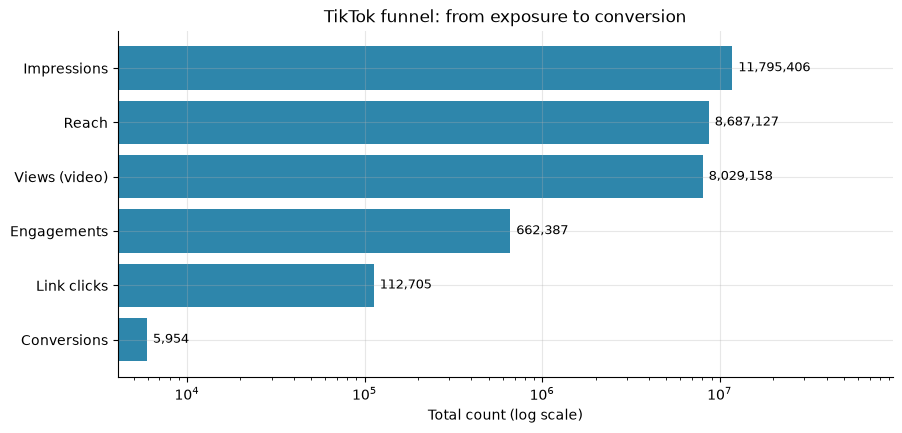

About 8.7% of the people reached engaged with a post, and only 0.048% of impressions ended in a conversion.
Note: bar totals add up whatever values exist in each column, so use the scorecard rates (matched rows) for exact ratios.


In [8]:
funnel = pd.Series({
    "Impressions": df["impressions"].sum(),
    "Reach": df["reach"].sum(),
    "Views (video)": df["views_v"].sum(),
    "Engagements": df["engagements"].sum(),
    "Link clicks": df["link_clicks"].sum(),
    "Conversions": df["conversions"].sum(),
})
fig, ax = plt.subplots()
bars = ax.barh(funnel.index[::-1], funnel.values[::-1], color=COLOR)
ax.set_xscale("log")
ax.set_xlabel("Total count (log scale)")
ax.set_title("TikTok funnel: from exposure to conversion")
for b, v in zip(bars, funnel.values[::-1]):
    ax.text(v * 1.08, b.get_y() + b.get_height() / 2, f"{v:,.0f}", va="center", fontsize=9)
ax.set_xlim(right=funnel.max() * 8)
plt.show()

conv_per_impr = ratio(df, "conversions", "impressions")[0]
print(f"About {avg['Engagement rate (reach) %']:.1f}% of the people reached engaged with a post, "
      f"and only {conv_per_impr:.3f}% of impressions ended in a conversion.")
print("Note: bar totals add up whatever values exist in each column, so use the scorecard rates (matched rows) for exact ratios.")

## 6. Content format comparison

Which format earns the most engagement per person reached?

In [9]:
def group_table(d, by):
    key = d[by].rename("_group")          # separate key so the column stays available inside each group
    out = {}
    for name, (n, dn, s) in SPEC.items():
        out[name] = d.groupby(key, observed=True).apply(lambda g: ratio(g, n, dn, s)[0], include_groups=False)
    t = pd.DataFrame(out)
    t.index.name = by
    t.insert(0, "posts", d.groupby(key, observed=True).size())
    return t

by_format = group_table(df, "content_format")
by_format.round(2)

,posts,Frequency,Engagement rate (reach) %,Engagement rate (impressions) %,Engagement rate (followers) %,Amplification rate %,View rate % (video),Completion rate % (video),CTR %,Conversion rate %,Follower growth rate %
content_format,,,,,,,,,,,
image,25,1.32,6.15,4.75,2.82,0.19,NaN,NaN,0.98,4.88,0.11
text,13,1.31,3.59,2.71,0.81,0.06,NaN,NaN,1.00,4.56,0.04
video,196,1.37,9.08,6.55,5.14,0.34,72.28,44.72,0.97,4.99,0.13


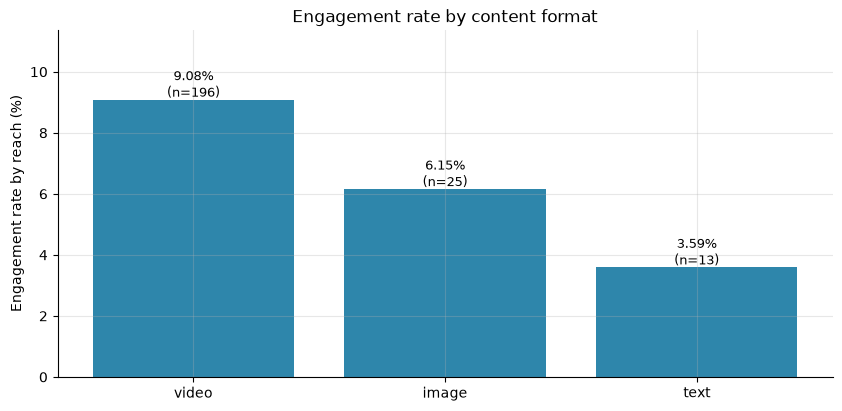

'video' posts lead with 9.08% engagement rate by reach, 2.5x the rate of 'text' (3.59%).
Check the n values: a format with very few posts is a weak basis for a conclusion.


In [10]:
order = by_format["Engagement rate (reach) %"].sort_values(ascending=False)
fig, ax = plt.subplots()
bars = ax.bar(order.index, order.values, color=COLOR)
ax.set_ylabel("Engagement rate by reach (%)")
ax.set_title("Engagement rate by content format")
for b, fmt in zip(bars, order.index):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.1,
            f"{b.get_height():.2f}%\n(n={by_format.loc[fmt, 'posts']})", ha="center", fontsize=9)
ax.set_ylim(0, order.max() * 1.25)
plt.show()

best, worst = order.index[0], order.index[-1]
print(f"'{best}' posts lead with {order.iloc[0]:.2f}% engagement rate by reach, "
      f"{order.iloc[0] / order.iloc[-1]:.1f}x the rate of '{worst}' ({order.iloc[-1]:.2f}%).")
print("Check the n values: a format with very few posts is a weak basis for a conclusion.")

## 7. Account comparison

,posts,Engagement rate (reach) %,Engagement rate (followers) %,Amplification rate %,Follower growth rate %,CTR %
account_id,,,,,,
ACC03,109,8.63,4.77,0.34,0.12,0.96
ACC04,125,8.76,4.68,0.30,0.12,0.98


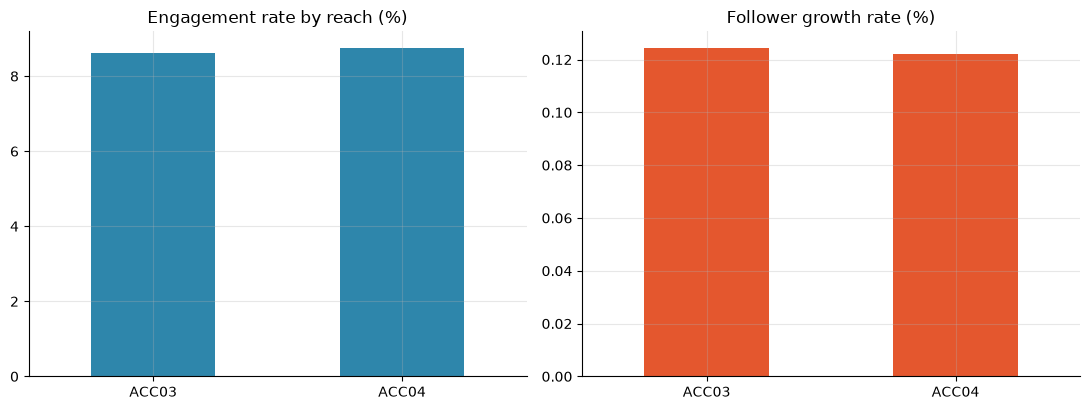

Engagement rate by followers: ACC03 = 4.77% vs ACC04 = 4.68% (a 2% relative gap). This metric is the fairest way to compare accounts of different sizes.
The accounts perform about the same.


In [11]:
by_account = group_table(df, "account_id")
display(by_account[["posts", "Engagement rate (reach) %", "Engagement rate (followers) %",
                    "Amplification rate %", "Follower growth rate %", "CTR %"]].round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
by_account["Engagement rate (reach) %"].plot.bar(ax=axes[0], color=COLOR, rot=0)
axes[0].set_title("Engagement rate by reach (%)")
by_account["Follower growth rate %"].plot.bar(ax=axes[1], color=ACCENT, rot=0)
axes[1].set_title("Follower growth rate (%)")
for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

a = by_account["Engagement rate (followers) %"]
gap = (a.max() - a.min()) / a.min() * 100
print(f"Engagement rate by followers: {a.idxmax()} = {a.max():.2f}% vs {a.idxmin()} = {a.min():.2f}% "
      f"(a {gap:.0f}% relative gap). This metric is the fairest way to compare accounts of different sizes.")
print("The accounts perform about the same." if gap < 10 else f"{a.idxmax()} clearly outperforms {a.idxmin()} per follower.")

## 8. When to post: time patterns

Time-of-day bands and weekdays are used instead of exact hours, because 24 hourly groups are too small to be reliable.

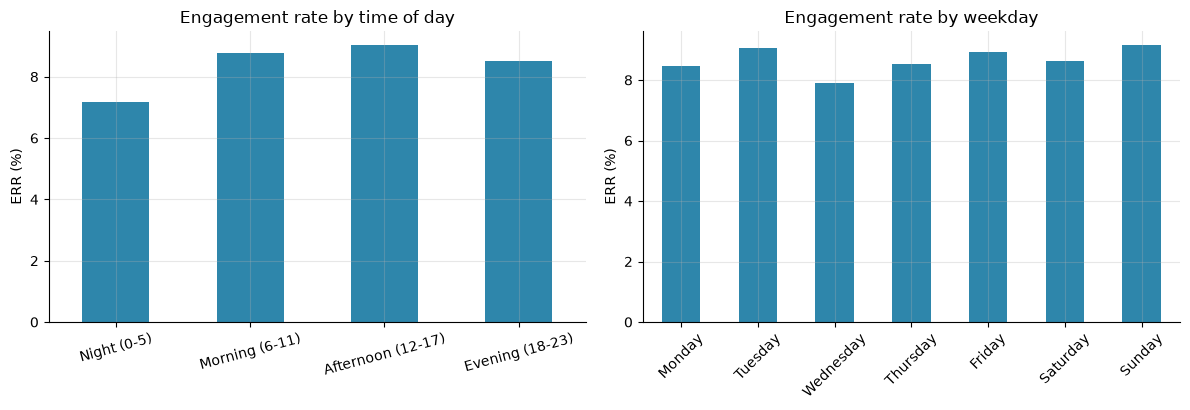

Best time of day: Afternoon (12-17) (9.03%); weakest: Night (0-5) (7.18%).
Best weekday: Sunday (9.15%); weakest: Wednesday (7.89%).
The spread is 1.26 points across weekdays and 1.85 points across day parts, versus 5.50 points across content formats.
Content format matters far more than posting time here.


In [12]:
by_daypart = group_table(df, "daypart")
by_weekday = group_table(df, "weekday")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
by_daypart["Engagement rate (reach) %"].plot.bar(ax=axes[0], color=COLOR, rot=15)
axes[0].set_title("Engagement rate by time of day")
axes[0].set_xlabel("")
by_weekday["Engagement rate (reach) %"].plot.bar(ax=axes[1], color=COLOR, rot=45)
axes[1].set_title("Engagement rate by weekday")
axes[1].set_xlabel("")
for ax in axes:
    ax.set_ylabel("ERR (%)")
plt.tight_layout()
plt.show()

d, w = by_daypart["Engagement rate (reach) %"], by_weekday["Engagement rate (reach) %"]
print(f"Best time of day: {d.idxmax()} ({d.max():.2f}%); weakest: {d.idxmin()} ({d.min():.2f}%).")
print(f"Best weekday: {w.idxmax()} ({w.max():.2f}%); weakest: {w.idxmin()} ({w.min():.2f}%).")
fmt_spread = by_format["Engagement rate (reach) %"].max() - by_format["Engagement rate (reach) %"].min()
print(f"The spread is {w.max() - w.min():.2f} points across weekdays and {d.max() - d.min():.2f} points across day parts, "
      f"versus {fmt_spread:.2f} points across content formats.")
print("Content format matters far more than posting time here." if fmt_spread > 2 * max(w.max() - w.min(), d.max() - d.min())
      else "Timing and format have effects of similar size.")

## 9. Trend over time

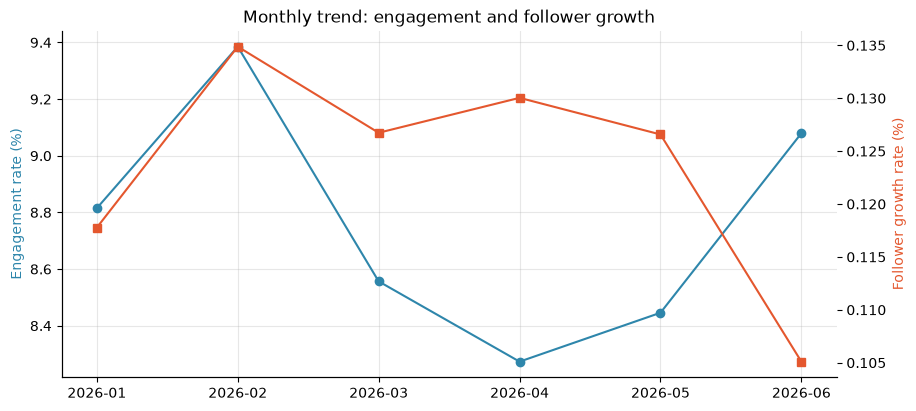

Engagement rate moved from 8.81% in 2026-01 to 9.08% in 2026-06 (+0.26 points).
Month-to-month range: 8.27% to 9.39%. The trend is essentially flat.


In [13]:
by_month = group_table(df, "month")

fig, ax1 = plt.subplots()
ax1.plot(by_month.index, by_month["Engagement rate (reach) %"], marker="o", color=COLOR, label="Engagement rate (reach) %")
ax1.set_ylabel("Engagement rate (%)", color=COLOR)
ax2 = ax1.twinx()
ax2.plot(by_month.index, by_month["Follower growth rate %"], marker="s", color=ACCENT, label="Follower growth rate %")
ax2.set_ylabel("Follower growth rate (%)", color=ACCENT)
ax2.grid(False)
ax1.set_title("Monthly trend: engagement and follower growth")
plt.show()

first, last = by_month.index[0], by_month.index[-1]
e = by_month["Engagement rate (reach) %"]
change = e.iloc[-1] - e.iloc[0]
print(f"Engagement rate moved from {e.iloc[0]:.2f}% in {first} to {e.iloc[-1]:.2f}% in {last} ({change:+.2f} points).")
print(f"Month-to-month range: {e.min():.2f}% to {e.max():.2f}%. "
      + ("The trend is essentially flat." if e.max() - e.min() < 1.5 else "There is a visible trend worth investigating."))

## 10. Video performance: hook and retention

View rate shows whether people start watching. Completion rate shows whether they stay. Video length is the main lever.

,posts,View rate % (video),Completion rate % (video),Engagement rate (reach) %
video_length_sec,,,,
15,40,72.03,45.12,9.04
30,28,73.57,47.05,9.33
45,20,75.92,43.53,9.12
60,26,72.72,46.31,9.75
90,19,68.62,55.42,8.96
180,33,71.48,41.61,8.95
300,30,72.18,44.28,8.61


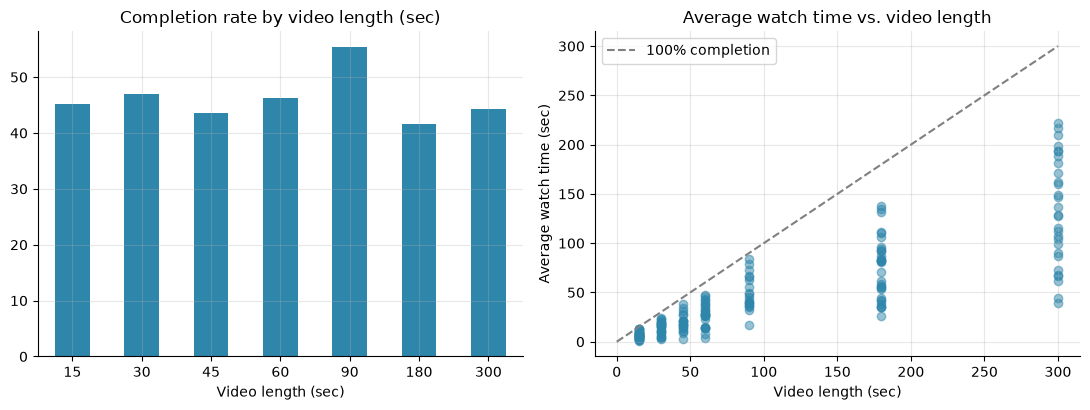

Completion rate is highest for 90-second videos (55.4%) and lowest for 180-second videos (41.6%).
Correlation between video length and completion rate: -0.05. Length has little effect on completion in this data; differences between lengths are mostly noise.


In [14]:
videos = df[is_video].copy()
videos["video_length_sec"] = videos["video_length_sec"].astype(int)
by_len = group_table(videos, "video_length_sec")
display(by_len[["posts", "View rate % (video)", "Completion rate % (video)",
                "Engagement rate (reach) %"]].round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
by_len["Completion rate % (video)"].plot.bar(ax=axes[0], color=COLOR, rot=0)
axes[0].set_title("Completion rate by video length (sec)")
axes[0].set_xlabel("Video length (sec)")
axes[1].scatter(videos["video_length_sec"], videos["avg_watch_time_sec"], alpha=0.5, color=COLOR)
axes[1].plot([0, 300], [0, 300], "--", color="gray", label="100% completion")
axes[1].set_title("Average watch time vs. video length")
axes[1].set_xlabel("Video length (sec)")
axes[1].set_ylabel("Average watch time (sec)")
axes[1].legend()
plt.tight_layout()
plt.show()

c = by_len["Completion rate % (video)"]
r_len = videos["video_length_sec"].corr(videos["completion"])
print(f"Completion rate is highest for {c.idxmax()}-second videos ({c.max():.1f}%) and lowest for "
      f"{c.idxmin()}-second videos ({c.min():.1f}%).")
print(f"Correlation between video length and completion rate: {r_len:.2f}. "
      + ("Longer videos are watched less completely." if r_len < -0.2 else
         "Length has little effect on completion in this data; differences between lengths are mostly noise."))

## 11. Frequency, engagement mix and distribution

**Frequency vs. engagement:** does showing a post to the same people repeatedly help?
**Engagement mix:** what kinds of interaction do viewers choose (likes are weak signals, shares and saves are strong)?

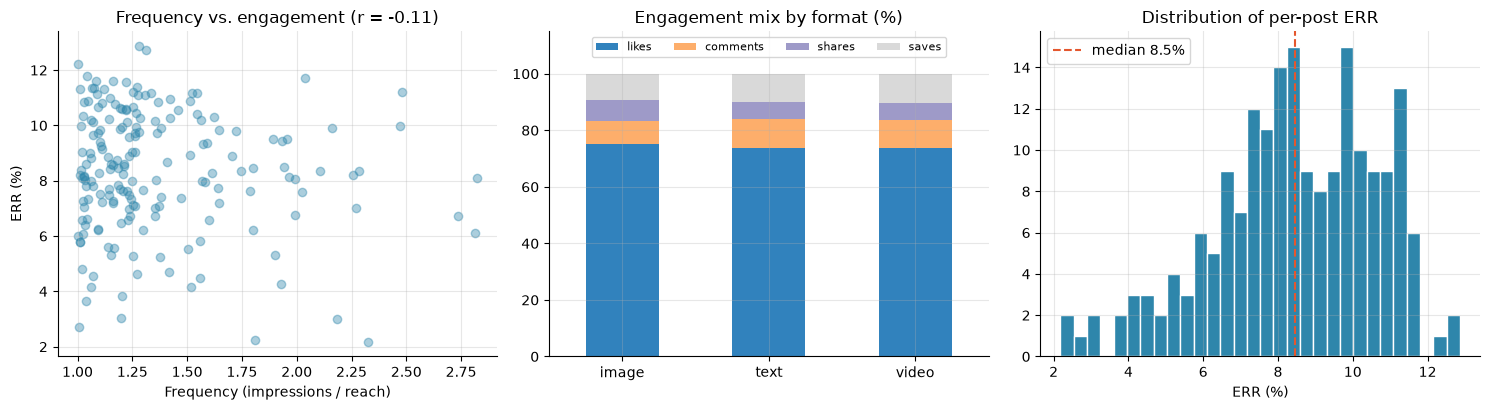

Correlation between frequency and ERR is -0.11: repeat exposure has little link with engagement rate.
Likes make up 74% of interactions on average; shares + saves (strong signals) make up 16%.


In [15]:
valid = df.dropna(subset=["frequency", "err"])
corr = valid["frequency"].corr(valid["err"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].scatter(valid["frequency"], valid["err"], alpha=0.4, color=COLOR)
axes[0].set_xlabel("Frequency (impressions / reach)")
axes[0].set_ylabel("ERR (%)")
axes[0].set_title(f"Frequency vs. engagement (r = {corr:.2f})")

mix = df.groupby("content_format")[["likes", "comments", "shares", "saves"]].sum()
mix = mix.div(mix.sum(axis=1), axis=0) * 100
mix.plot.bar(stacked=True, ax=axes[1], rot=0, colormap="tab20c")
axes[1].set_title("Engagement mix by format (%)")
axes[1].set_xlabel("")
axes[1].legend(loc="upper center", ncol=4, fontsize=8)
axes[1].set_ylim(0, 115)

axes[2].hist(df["err"].dropna(), bins=30, color=COLOR, edgecolor="white")
axes[2].axvline(df["err"].median(), color=ACCENT, ls="--", label=f"median {df['err'].median():.1f}%")
axes[2].set_title("Distribution of per-post ERR")
axes[2].set_xlabel("ERR (%)")
axes[2].legend()
plt.tight_layout()
plt.show()

print(f"Correlation between frequency and ERR is {corr:.2f}: "
      + ("higher repeat exposure is linked with higher engagement." if corr > 0.2 else
         "repeat exposure has little link with engagement rate." if corr > -0.2 else
         "repeat exposure is linked with lower engagement rate (fatigue)."))
print(f"Likes make up {mix['likes'].mean():.0f}% of interactions on average; "
      f"shares + saves (strong signals) make up {(mix['shares'] + mix['saves']).mean():.0f}%.")

## 12. Best and worst posts

In [16]:
cols = ["post_id", "account_id", "content_format", "reach", "engagements", "err", "ctr", "amplification"]
eligible = df.dropna(subset=["err"])
eligible = eligible[eligible["reach"] >= eligible["reach"].median()]   # ignore tiny-reach posts

print("Top 5 posts by engagement rate (reach above the median):")
display(eligible.nlargest(5, "err")[cols].round(2).reset_index(drop=True))
print("Bottom 5:")
display(eligible.nsmallest(5, "err")[cols].round(2).reset_index(drop=True))

Top 5 posts by engagement rate (reach above the median):


,post_id,account_id,content_format,reach,engagements,err,ctr,amplification
0,POST0020,ACC04,video,77436.0,9867.0,12.74,0.83,0.79
1,POST0284,ACC04,video,52708.0,6203.0,11.77,1.10,0.37
2,POST0979,ACC03,video,31103.0,3639.0,11.70,0.64,0.96
3,POST0644,ACC04,video,58511.0,6776.0,11.58,1.41,0.32
4,POST0335,ACC04,video,42214.0,4804.0,11.38,0.94,0.44


Bottom 5:


,post_id,account_id,content_format,reach,engagements,err,ctr,amplification
0,POST0474,ACC04,text,41778.0,1270.0,3.04,NaN,0.12
1,POST0960,ACC04,image,39149.0,1811.0,4.63,1.14,0.11
2,POST0563,ACC04,video,63763.0,3332.0,5.23,0.72,0.12
3,POST0076,ACC04,video,60915.0,3236.0,5.31,0.58,0.26
4,POST0114,ACC04,image,104306.0,5771.0,5.53,1.08,0.55


## 13. Single-post scorecard

A deep dive on the top-performing TikTok post, compared with the TikTok average. An index above 100 means better than average.

In [17]:
best_post = eligible.nlargest(1, "err").iloc[0]
compare = [("Frequency", "frequency"), ("Engagement rate (reach) %", "err"),
           ("Engagement rate (impressions) %", "er_impressions"),
           ("Engagement rate (followers) %", "er_followers"),
           ("Amplification rate %", "amplification"), ("View rate % (video)", "view_rate"),
           ("Completion rate % (video)", "completion"), ("CTR %", "ctr"),
           ("Conversion rate %", "conversion"), ("Follower growth rate %", "follower_growth")]

rows = []
for label, col in compare:
    post_val, avg_val = best_post[col], scorecard.loc[label, "value"]
    rows.append({"metric": label, "this post": round(post_val, 2) if pd.notna(post_val) else np.nan,
                 "TikTok average": avg_val,
                 "index (avg = 100)": round(post_val / avg_val * 100) if pd.notna(post_val) and avg_val else np.nan})
card = pd.DataFrame(rows).set_index("metric")

print(f"Post {best_post['post_id']} | account {best_post['account_id']} | {best_post['content_format']} | "
      f"posted {best_post['post_datetime']:%Y-%m-%d %H:%M}")
print(f"Reach {best_post['reach']:,.0f} | impressions {best_post['impressions']:,.0f} | "
      f"engagements {best_post['engagements']:,.0f}")
card

Post POST0020 | account ACC04 | video | posted 2026-01-04 08:15
Reach 77,436 | impressions 101,630 | engagements 9,867


,this post,TikTok average,index (avg = 100)
metric,,,
Frequency,1.31,1.37,96
Engagement rate (reach) %,12.74,8.73,146
Engagement rate (impressions) %,9.71,6.33,153
Engagement rate (followers) %,10.39,4.70,221
Amplification rate %,0.79,0.31,256
View rate % (video),88.00,72.28,122
Completion rate % (video),47.33,44.72,106
CTR %,0.83,0.97,85
Conversion rate %,6.06,4.97,122


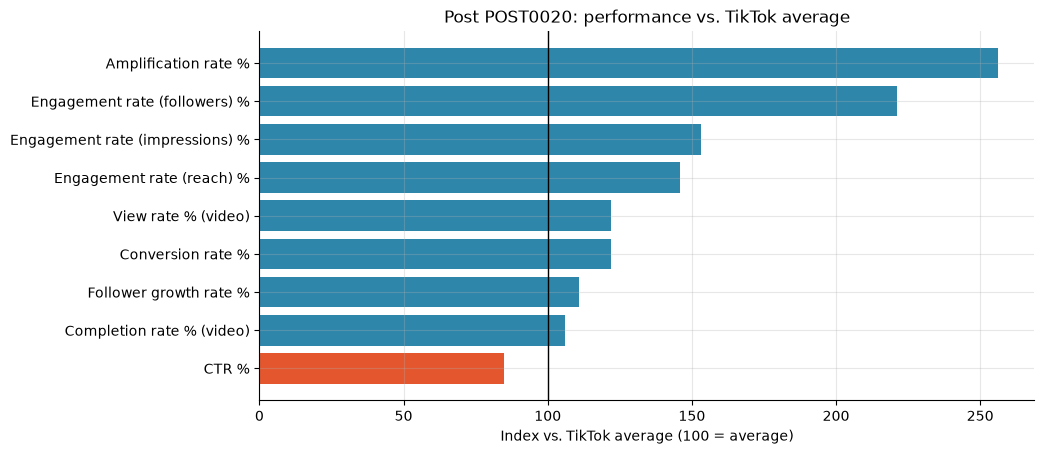

This post beats the TikTok average on 8 of 9 metrics that could be computed. Strongest: Amplification rate % (index 256); weakest: CTR % (index 85).


In [18]:
plot = card["index (avg = 100)"].drop("Frequency").dropna().sort_values()   # frequency is descriptive, not good/bad
fig, ax = plt.subplots(figsize=(10, 4.8))
colors = [COLOR if v >= 100 else ACCENT for v in plot.values]
ax.barh(plot.index, plot.values, color=colors)
ax.axvline(100, color="black", lw=1)
ax.set_xlabel("Index vs. TikTok average (100 = average)")
ax.set_title(f"Post {best_post['post_id']}: performance vs. TikTok average")
plt.show()

above = (plot >= 100).sum()
print(f"This post beats the TikTok average on {above} of {len(plot)} metrics that could be computed. "
      f"Strongest: {plot.idxmax()} (index {plot.max():.0f}); weakest: {plot.idxmin()} (index {plot.min():.0f}).")

## 14. Summary of findings and recommendations

In [19]:
fmt = by_format["Engagement rate (reach) %"]
acct = by_account["Engagement rate (followers) %"]
acct_gap = (acct.max() - acct.min()) / acct.min() * 100
dp = by_daypart["Engagement rate (reach) %"]
wd = by_weekday["Engagement rate (reach) %"]

summary = pd.DataFrame([
    ["Overall performance", f"ERR {avg['Engagement rate (reach) %']:.2f}%, frequency {avg['Frequency']:.2f}, CTR {avg['CTR %']:.2f}%",
     "Use these as the baseline for future posts"],
    ["Best format", f"{fmt.idxmax()} ({fmt.max():.2f}% ERR)", f"Prioritize {fmt.idxmax()} content"],
    ["Weakest format", f"{fmt.idxmin()} ({fmt.min():.2f}% ERR)", f"Reduce or rework {fmt.idxmin()} posts"],
    ["Account comparison", f"{acct.idxmax()} {acct.max():.2f}% vs {acct.idxmin()} {acct.min():.2f}% per follower",
     "No meaningful gap; look at other variables" if acct_gap < 10 else f"Study what {acct.idxmax()} does differently"],
    ["Best time of day", f"{dp.idxmax()} ({dp.max():.2f}%)", "Schedule key posts in this window"],
    ["Best weekday", f"{wd.idxmax()} ({wd.max():.2f}%)", "Test more posts on this day before committing"],
    ["Video retention", f"{avg['Completion rate % (video)']:.1f}% of video watched; length vs completion r = {r_len:.2f}",
     "Work on the opening seconds (hook); length is not the main driver" if r_len > -0.2 else "Shorten videos"],
], columns=["Area", "Finding", "Recommended action"]).set_index("Area")
summary

,Finding,Recommended action
Area,,
Overall performance,"ERR 8.73%, frequency 1.37, CTR 0.97%",Use these as the baseline for future posts
Best format,video (9.08% ERR),Prioritize video content
Weakest format,text (3.59% ERR),Reduce or rework text posts
Account comparison,ACC03 4.77% vs ACC04 4.68% per follower,No meaningful gap; look at other variables
Best time of day,Afternoon (12-17) (9.03%),Schedule key posts in this window
Best weekday,Sunday (9.15%),Test more posts on this day before committing
Video retention,44.7% of video watched; length vs completion r...,Work on the opening seconds (hook); length is ...


## Limits of this analysis

- The dataset is synthetic, so the patterns illustrate the method and should not be read as real TikTok benchmarks.
- Groups with few posts (see the `posts` column) can swing widely; treat those results as leads to test, not conclusions.
- Rows with missing or invalid values are excluded only from the metrics they affect, so `posts used` varies by metric.
- Correlation between two metrics does not show that one causes the other.
